In [1]:
%load_ext autoreload
%autoreload 2

from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.utils import load_arguments

plt.style.use("fluxoniumcr.plotting.paper")
plt.rcParams['figure.dpi'] = 192
%config InlineBackend.figure_format = 'png'

In [2]:
EJ=4.0 * 2*pi
EC=1.0 * 2*pi
EL=1.0 * 2*pi

fluxonium = Fluxonium(
    EJ=EJ,
    EC=EC,
    EL=EL,
    flux=0.5,
    dim=6,
    cutoff=128,
)

E = fluxonium.eigenvalues

In [3]:
parent_path = DATA_DIR/"polarization_spectrum/EJ=4.0,EC=1.0,EL=1.0"
argm = load_arguments(parent_path)
ds = xr.load_dataset(parent_path/"dataset.hdf5")

fx = Fluxonium(
    EJ=argm.EJ,
    EC=argm.EC,
    EL=argm.EL,
    dim=argm.dim,
    cutoff=argm.cutoff
)
E = fluxonium.eigenvalues

resonances = [
    ((E[1] - E[0])/3, r"$\frac{f_{10}}{3}$"),
    ((E[1] - E[0]), "$f_{10}$"),
    ((E[2] - E[0])/4, r"$\frac{f_{20}}{4}$"),
#     ((E[2] - E[1])/5, "$f_{21}/5$"),
    ((E[2] - E[0])/2, r"$\frac{f_{20}}{2}$"),
    ((E[2] - E[1])/3, r"$\frac{f_{21}}{3}$"),
    
#     ((E[3] - E[0])/5, r"$\dfrac{f_{30}}{5}$"),
    ((E[3] - E[1])/4, r"$\frac{f_{31}}{4}$"),
    ((E[3] - E[0])/3, r"$\frac{f_{30}}{3}$"),
    ((E[3] - E[1])/2, r"$\frac{f_{31}}{2}$"),
    
    ((E[4] - E[0])/4, r"$\frac{f_{40}}{4}$"),
#     ((E[4] - E[1])/5, r"$\dfrac{f_{41}}{5}$"),
    ((E[4] - E[0])/2, r"$\frac{f_{40}}{2}$"),
#     ((E[4] - E[1])/3, r"$\dfrac{f_{41}}{3}$"),
    
    ((E[5] - E[0])/5, r"$\frac{f_{50}}{5}$"),
    ((E[5] - E[1])/4, r"$\frac{f_{51}}{4}$"),
    ((E[5] - E[0])/3, r"$\frac{f_{50}}{3}$"),
    ((E[5] - E[1])/2, r"$\frac{f_{51}}{2}$"),
]

In [4]:
conditional_polarization_magn = abs(ds.p1 - ds.p0)
objective = ds.error/conditional_polarization_magn
amplitude = ds.amplitude

In [5]:
plt.rcParams.update({
    "text.usetex": False,
    "pgf.rcfonts": False,
    "pgf.texsystem": "lualatex",
    "pgf.preamble": "\n".join([
        r"\usepackage{unicode-math}",
#         r"\setsansfont[BoldFont={FiraGO Light}]{FiraGO}",
        # r"\setmathfont{Libertinus Math}",
        # r"\usepackage[p,osf]{fbb}",
        r"\setmathfont{Fira Math}[Scale=0.9]",
        r"\setmathfontface\mathrm{Fira Math}[Scale=0.9]",
        r"\usepackage[sfdefault,scaled=0.9]{FiraSans}",
        r"\setmathfont[range={\star}]{STIX Two Math}",
        r"\newfontfamily\mylabelfont{FiraGo Medium}",
    ]),
    "lines.solid_capstyle": "round",
})

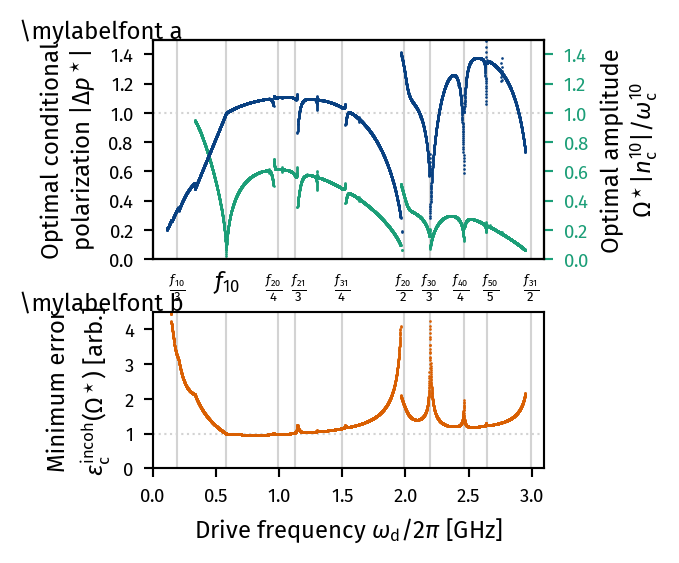

In [6]:
mask = (ds.frequency < 2.95 * 2*pi) & (ds.frequency > 0.11 * (2*pi))

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(85/25.4, 70/25.4),
    sharex=True,
    gridspec_kw=dict(
        height_ratios=(1.4, 1),
    )
)

ax1.plot(
    conditional_polarization_magn.frequency[mask] / (2*pi),
    conditional_polarization_magn[mask],
    markersize=2,
    marker='.',
    linestyle='',
    markeredgecolor='none',
    rasterized=True,
)

ax1.set_yticks(np.arange(0.0, 1.5, 0.2))
ax1.set_ylim(0.0, 1.5)

ax1.tick_params(axis='x', bottom=False)
ax1.set_ylabel("Optimal conditional\npolarization $|\\Delta p^\star|$")

ax1b = ax1.twinx()
ax1.patch.set_visible(False)
ax1.set_zorder(1)
ax1b.plot(
    amplitude.frequency[mask] / (2*pi),
    amplitude[mask]/amplitude.attrs['plot_unit'],
    markersize=2,
    marker='.',
    linestyle='',
    markeredgecolor='none',
    c='C4',
    rasterized=True,
)
ax1b.set_yticks(np.arange(0, 1.2, 0.2))
ax1b.set_ylim(0, 1.1)

ax1b.set_yticks(np.arange(0, 1.5, 0.2))
ax1b.set_ylim(0, 1.5)

ax1b.tick_params(axis='y', colors='C4', which='both')
ax1b.set_ylabel("Optimal amplitude\n" + r"$\Omega^\star |n^{10}_\mathrm{c}|/\omega^{10}_\mathrm{c}$")

ax1.yaxis.set_major_formatter("${0:.1f}$".format)
ax1b.yaxis.set_major_formatter("${0:.1f}$".format)

ax2.plot(
    objective.frequency[mask] / (2*pi),
    objective[mask] / objective[objective.frequency.searchsorted(E[1] - E[0])].item(),
    markersize=2,
    marker='.',
    linestyle='',
    markeredgecolor='none',
    c='C1',
#     zorder=-1,
    rasterized=True,
)
ax2.set_xticks(np.arange(0, 3.5, 0.5))
ax2.set_yticks(np.arange(5))
ax2.set_xlim(0, 3.1)
ax2.set_ylim(0, 4.5)
ax2.xaxis.set_major_formatter("${0:.1f}$".format)

ax2.set_ylabel("Minimum error\n$\epsilon^\\mathrm{incoh}_\\mathrm{c}(\Omega^\star)$ [arb.]")
ax2.yaxis.label.set_linespacing(1.4)
ax2.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$ [GHz]")


resonances_clipped = [
    (x, label) for x, label in resonances
    if x/(2*pi) <= ax2.get_xlim()[1] and x/(2*pi) >= ax2.get_xlim()[0]
]

for x, label in resonances_clipped:
    ax1b.axvline(
        x/(2*pi),
        zorder=-1,
        c='lightgray',
        lw=plt.rcParams['grid.linewidth'],
    )
    ax2.axvline(
        x/(2*pi),
        zorder=-1,
        c='lightgray',
        lw=plt.rcParams['grid.linewidth'],
    )
    
    x_offset = 0
    for y, _ in resonances_clipped:
        if x == y: continue
        if abs(x - y) < 1.2:
            if x > y:
                x_offset = 1.5
            else:
                x_offset = -1.5
    
    y_offset = 3 if 'frac' not in label else 0
    
    ax2.annotate(
        label,
        (x/(2*pi), ax2.get_ylim()[1]),
        (x_offset, 3 + y_offset),
        textcoords='offset points',
        annotation_clip=False,
        ha='center',
        va='bottom',
        fontsize=plt.rcParams['xtick.labelsize'] if 'frac' in label else None
    )

ax1b.axhline(
    1.0 * ax1b.get_ylim()[1]/ax1.get_ylim()[1],
    zorder=-1,
    c='lightgray',
    lw=plt.rcParams['grid.linewidth'],
    ls=':',
)
ax2.axhline(
    1,
    zorder=-1,
    c='lightgray',
    lw=plt.rcParams['grid.linewidth'],
    ls=':',
)

fig.subplots_adjust(
    left=0.19 + 0.02,
    right=0.82,
    bottom=0.14,
    top=0.95,
    hspace=0.28,
)

for ax, label in zip((ax1, ax2), ("a", "b")):
    ax.annotate(
        r"\mylabelfont " + label,
#         label,
        xy=(0, 1),
        xycoords='axes fraction',
        xytext=(-50, 8),
        textcoords='offset points',
#         fontweight='bold',
        va='top',
    )

plt.savefig("polarization_spectrum.pdf", backend='pgf', dpi=600)